In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
sotj_2021_data = pd.read_csv('../output/tables/2024/Scaling_Mario/SOTJ_sample_countries_2021.csv')

tor_vote = pd.read_excel('../output/tables/2024/Scaling_Mario/TOR_Vote_Population.xlsx')
# Drop TOR_vote_dummy column
tor_vote = tor_vote.drop(columns=['TOR_vote_dummy'])
# Drop rows with NaN values
tor_vote = tor_vote.dropna()
# Rename iso3 as iso_partner
tor_vote = tor_vote.rename(columns={'iso3':'iso_partner'})

tor_vote


,iso_partner,population,TOR_vote
0,AGO,36684202.0,Yes
1,AZE,10112555.0,Yes
2,BDI,13238559.0,Yes
3,BFA,23251485.0,Yes
4,BGD,172954319.0,Yes
...,...,...,...
157,SVN,2120937.0,Abstention
158,SWE,10536632.0,Abstention
159,TTO,1534937.0,Abstention
160,TUR,85326000.0,Abstention


In [3]:
# Merge the two dataframes
sotj_tor_data_2021 = sotj_2021_data.merge(tor_vote, on='iso_partner', how='left')

# View all columns
pd.set_option('display.max_columns', None)

sotj_tor_data_2021

# Keep iso_partner, ukt, population, tax_revenue_loss_caused_pct_of_total and TOR_vote
sotj_tor_data_2021 = sotj_tor_data_2021[['iso_partner', 'ukt', 'population', 'tax_revenue_loss_caused_usd', 'tax_revenue_loss_caused_pct_of_total', 'TOR_vote']]


# If ukt = 1, make TOR_vote = No
sotj_tor_data_2021['TOR_vote'] = sotj_tor_data_2021.apply(lambda x: 'No' if x['ukt'] == 1 else x['TOR_vote'], axis=1)
sotj_tor_data_2021['TOR_vote'] = sotj_tor_data_2021.apply(lambda x: 'No' if x['ukt'] == 1 else x['TOR_vote'], axis=1)


# If iso_partner is PRI, GUM, VIR and ASM, make TOR_vote = 2
sotj_tor_data_2021['TOR_vote'] =  sotj_tor_data_2021.apply(lambda x: 'No' if x['iso_partner'] in ['PRI', 'GUM', 'VIR', 'ASM'] else x['TOR_vote'], axis=1)

# Show if TOR_vote = No

# Create a new column with the sum of tax_revenue_loss_caused_usd
sotj_tor_data_2021['tax_revenue_loss_caused_usd'].sum()

# Add a new column name sum_tax_revenue_loss_caused_usd which is the sum of tax_revenue_loss_caused_usd
sotj_tor_data_2021['sum_tax_revenue_loss_caused_usd'] = sotj_tor_data_2021['tax_revenue_loss_caused_usd'].sum()

sotj_tor_data_2021


,iso_partner,ukt,population,tax_revenue_loss_caused_usd,tax_revenue_loss_caused_pct_of_total,TOR_vote,sum_tax_revenue_loss_caused_usd
0,ABW,0.0,NaN,0.000000,0.000000,NaN,347578.913647
1,AFG,0.0,NaN,0.750641,0.000002,NaN,347578.913647
2,AGO,0.0,36684202.0,80.661505,0.000232,Yes,347578.913647
3,AIA,1.0,NaN,0.000000,0.000000,No,347578.913647
4,ALB,0.0,2745972.0,1.051978,0.000003,Abstention,347578.913647
...,...,...,...,...,...,...,...
206,XKV,0.0,NaN,0.830475,0.000002,NaN,347578.913647
207,YEM,0.0,34449825.0,0.496956,0.000001,Yes,347578.913647
208,ZAF,0.0,60414495.0,4621.596673,0.013297,Yes,347578.913647
209,ZMB,0.0,20569737.0,0.000000,0.000000,Yes,347578.913647


In [4]:
cbcr_sample = pd.read_csv('../data/final/2024/cbcr_main_no_imputation_allsubgroupsonly.csv')

# Show me numbers in non-scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

# Keep if year == 2021
cbcr_sample = cbcr_sample[cbcr_sample['year'] == 2021]

# Keep only the columns we need: iso_parent, iso_partner, gdp, gdp_current_usd
cbcr_sample = cbcr_sample[['iso_partner', 'gdp_current_usd', 'population']]

# Sort by iso_partner
cbcr_sample = cbcr_sample.sort_values(by='iso_partner')

# Drop duplicates
cbcr_sample = cbcr_sample.drop_duplicates()


cbcr_sample




,iso_partner,gdp_current_usd,population
765,A,NaN,NaN
3578,ABW,3103184101.51,106537.00
4148,AFG,14266499429.87,40099462.00
12236,AGO,66505129987.72,34503774.00
797,AIA,380000000.00,14500.00
...,...,...,...
4948,XKV,9420000000.00,1786038.00
13186,YEM,26588738327.26,32981641.00
12228,ZAF,420117812466.04,59392255.00
9953,ZMB,22096416932.01,19473125.00


In [5]:
# Merge the two dataframes
killer_graph_data = sotj_tor_data_2021.merge(cbcr_sample, on='iso_partner', how='left')

# Drop population_x column
killer_graph_data = killer_graph_data.drop(columns=['population_x'])

# Rename population_y as population
killer_graph_data = killer_graph_data.rename(columns={'population_y':'population'})

# Divide gdp_current_usd by 1000000 to get gdp in millions
killer_graph_data['gdp_current_usd'] = killer_graph_data['gdp_current_usd'] / 1000000


killer_graph_data

,iso_partner,ukt,tax_revenue_loss_caused_usd,tax_revenue_loss_caused_pct_of_total,TOR_vote,sum_tax_revenue_loss_caused_usd,gdp_current_usd,population
0,ABW,0.00,0.00,0.00,NaN,347578.91,3103.18,106537.00
1,AFG,0.00,0.75,0.00,NaN,347578.91,14266.50,40099462.00
2,AGO,0.00,80.66,0.00,Yes,347578.91,66505.13,34503774.00
3,AIA,1.00,0.00,0.00,No,347578.91,380.00,14500.00
4,ALB,0.00,1.05,0.00,Abstention,347578.91,17930.57,2811666.00
...,...,...,...,...,...,...,...,...
206,XKV,0.00,0.83,0.00,NaN,347578.91,9420.00,1786038.00
207,YEM,0.00,0.50,0.00,Yes,347578.91,26588.74,32981641.00
208,ZAF,0.00,4621.60,0.01,Yes,347578.91,420117.81,59392255.00
209,ZMB,0.00,0.00,0.00,Yes,347578.91,22096.42,19473125.00


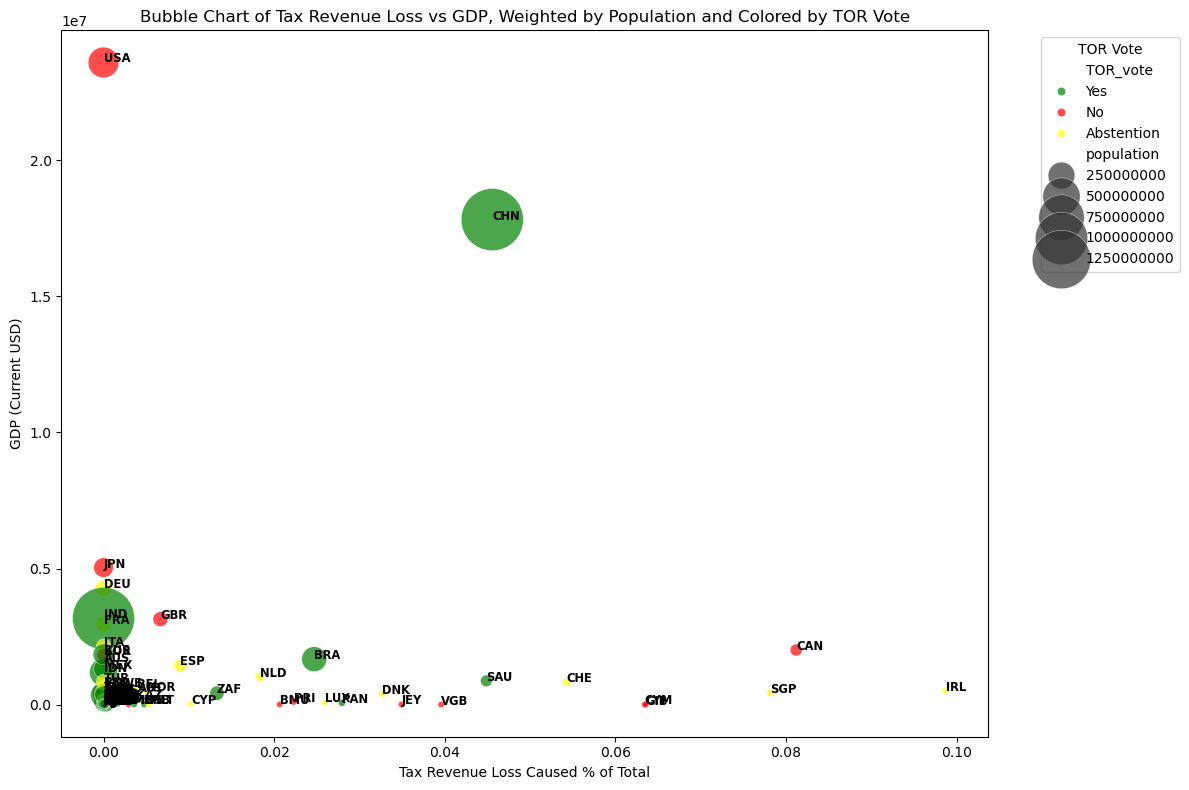

In [6]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = killer_graph_data.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'yellow', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='tax_revenue_loss_caused_pct_of_total',
    y='gdp_current_usd',
    size='population',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Tax Revenue Loss Caused % of Total')
plt.ylabel('GDP (Current USD)')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add annotations
for line in range(0, filtered_data.shape[0]):
    plt.text(
        filtered_data.tax_revenue_loss_caused_pct_of_total.iloc[line],
        filtered_data.gdp_current_usd.iloc[line],
        filtered_data.iso_partner.iloc[line],
        horizontalalignment='left',
        size='small',
        color='black',
        weight='semibold'
    )

# Show the plot
plt.tight_layout()
plt.show()

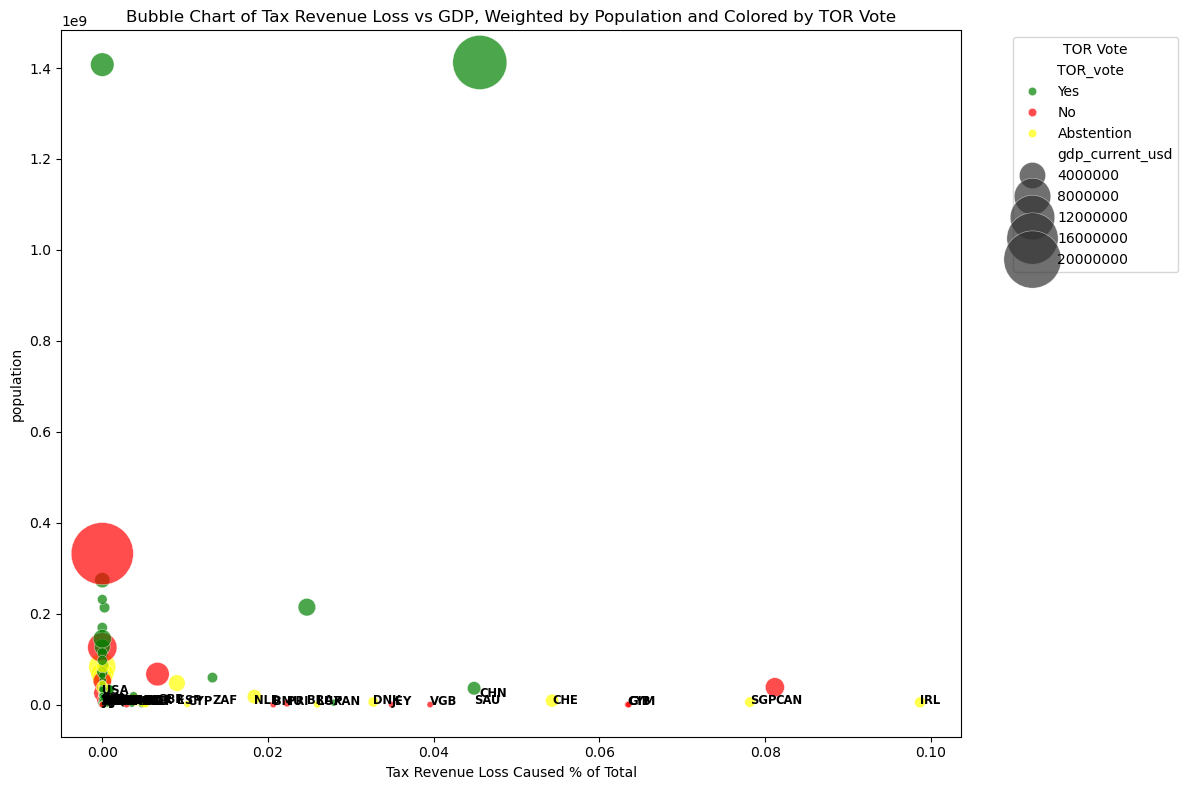

In [7]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = killer_graph_data.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'yellow', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='tax_revenue_loss_caused_pct_of_total',
    y='population',
    size='gdp_current_usd',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Tax Revenue Loss Caused % of Total')
plt.ylabel('population')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add annotations
for line in range(0, filtered_data.shape[0]):
    plt.text(
        filtered_data.tax_revenue_loss_caused_pct_of_total.iloc[line],
        filtered_data.gdp_current_usd.iloc[line],
        filtered_data.iso_partner.iloc[line],
        horizontalalignment='left',
        size='small',
        color='black',
        weight='semibold'
    )

# Show the plot
plt.tight_layout()
plt.show()

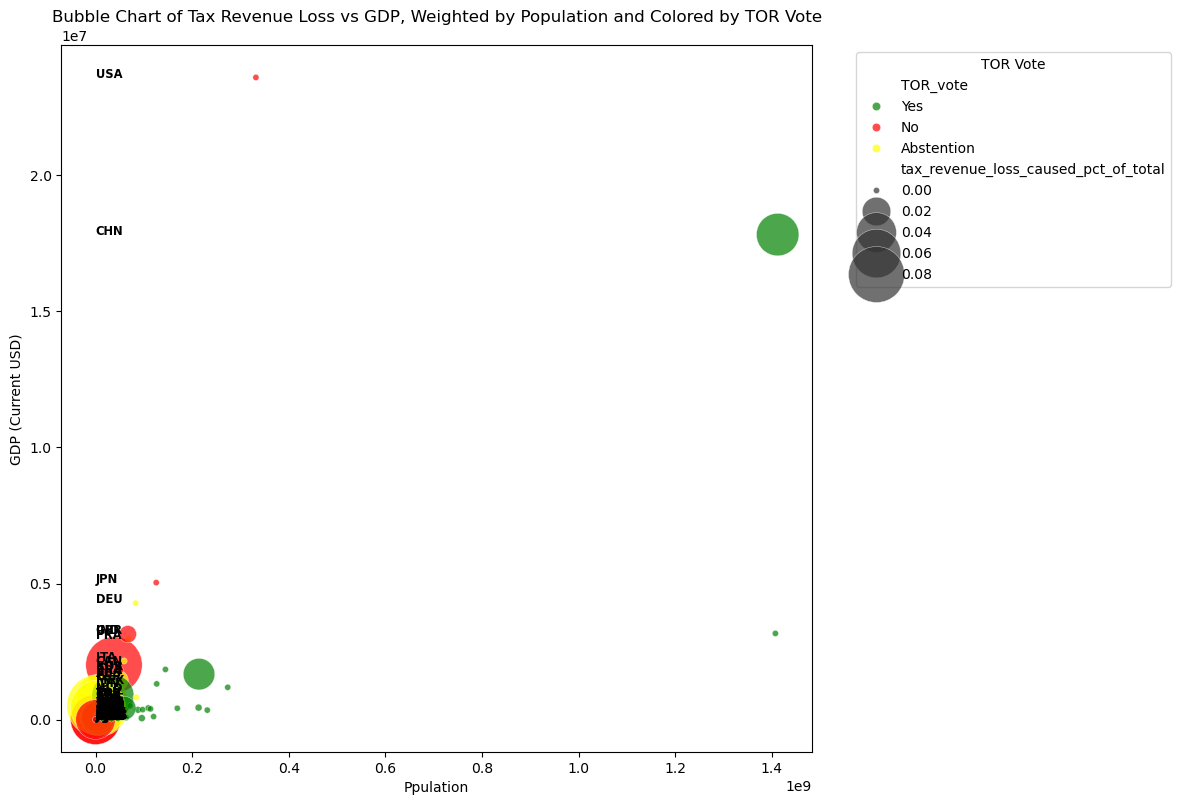

In [8]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = killer_graph_data.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'yellow', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='population',
    y='gdp_current_usd',
    size='tax_revenue_loss_caused_pct_of_total',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Ppulation')
plt.ylabel('GDP (Current USD)')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add annotations
for line in range(0, filtered_data.shape[0]):
    plt.text(
        filtered_data.tax_revenue_loss_caused_pct_of_total.iloc[line],
        filtered_data.gdp_current_usd.iloc[line],
        filtered_data.iso_partner.iloc[line],
        horizontalalignment='left',
        size='small',
        color='black',
        weight='semibold'
    )

# Show the plot
plt.tight_layout()
plt.show()

In [9]:
# Aggregrate killer_graph_data by TOR_vote
grouped_data = killer_graph_data.groupby('TOR_vote').agg(
    population=('population', 'sum'),
    gdp_current_usd=('gdp_current_usd', 'sum'),
    tax_revenue_loss_caused_usd=('tax_revenue_loss_caused_usd', 'sum'),
).reset_index() # Reset the index to make TOR_vote a column 

# Add a new column name sum_tax_revenue_loss_caused_usd which is the sum of tax_revenue_loss_caused_usd
grouped_data['sum_tax_revenue_loss_caused_usd'] = grouped_data['tax_revenue_loss_caused_usd'].sum()

# Generate new column which is tax_revenue_loss_caused_usd divided by sum_tax_revenue_loss_caused_usd
grouped_data['share_tax_revenue_loss_caused_usd_pct'] = grouped_data['tax_revenue_loss_caused_usd'] / grouped_data['sum_tax_revenue_loss_caused_usd']

# Generate new column which is population divided by sum of population
grouped_data['share_population_pct'] = grouped_data['population'] / grouped_data['population'].sum()

# Generate new column which is gdp_current_usd divided by sum of gdp_current_usd
grouped_data['share_gdp_current_usd_pct'] = grouped_data['gdp_current_usd'] / grouped_data['gdp_current_usd'].sum()

grouped_data


,TOR_vote,population,gdp_current_usd,tax_revenue_loss_caused_usd,sum_tax_revenue_loss_caused_usd,share_tax_revenue_loss_caused_usd_pct,share_population_pct,share_gdp_current_usd_pct
0,Abstention,669715764.00,21113083.64,122665.37,301499.63,0.41,0.09,0.22
1,No,659028331.00,38054247.45,116482.18,301499.63,0.39,0.09,0.40
2,Yes,6278434338.00,36386049.37,62352.09,301499.63,0.21,0.83,0.38


In [10]:
# Assuming grouped_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = grouped_data.dropna(subset=['TOR_vote', 'share_tax_revenue_loss_caused_usd_pct', 'share_population_pct', 'share_gdp_current_usd_pct'])

# Melt the DataFrame to long format
melted_data = filtered_data.melt(id_vars=['TOR_vote'], 
                                 value_vars=['share_tax_revenue_loss_caused_usd_pct', 'share_population_pct', 'share_gdp_current_usd_pct'],
                                 var_name='Variable', 
                                 value_name='Value')

# Pivot the melted DataFrame to wide format
pivot_data = melted_data.pivot(index='TOR_vote', columns='Variable', values='Value').reset_index()

# Drop share_gdp_current_usd_pct
pivot_data = pivot_data.drop(columns=['share_gdp_current_usd_pct'])

pivot_data


Variable,TOR_vote,share_population_pct,share_tax_revenue_loss_caused_usd_pct
0,Abstention,0.09,0.41
1,No,0.09,0.39
2,Yes,0.83,0.21


In [11]:
#pivot_data to excel
pivot_data.to_excel('voters_share_population_tax_revenue_loss.xlsx', index=False)

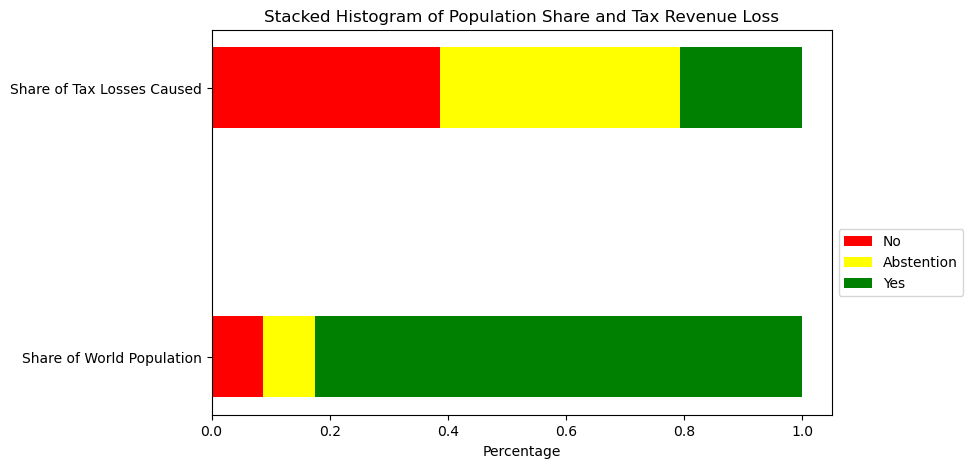

In [12]:
pivot_data = pivot_data.set_index('TOR_vote').loc[['No', 'Abstention', 'Yes']]

# Colors dictionary
colors = {'No': 'red', 'Abstention': 'yellow', 'Yes': 'green'}

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

# Plotting the first column: share_population_pct
ax.barh(y=0, width=pivot_data['share_population_pct']['No'], color=colors['No'], label='No', height=0.3)
ax.barh(y=0, width=pivot_data['share_population_pct']['Abstention'], color=colors['Abstention'],
    left=pivot_data['share_population_pct']['No'], label='Abstention', height=0.3)
ax.barh(y=0, width=pivot_data['share_population_pct']['Yes'], color=colors['Yes'],
    left=pivot_data['share_population_pct']['No'] + pivot_data['share_population_pct']['Abstention'], label='Yes', height=0.3)

# Plotting the second column: share_tax_revenue_loss_caused_usd_pct
ax.barh(y=1, width=pivot_data['share_tax_revenue_loss_caused_usd_pct']['No'], color=colors['No'], height=0.3)
ax.barh(y=1, width=pivot_data['share_tax_revenue_loss_caused_usd_pct']['Abstention'], color=colors['Abstention'],
    left=pivot_data['share_tax_revenue_loss_caused_usd_pct']['No'], height=0.3)
ax.barh(y=1, width=pivot_data['share_tax_revenue_loss_caused_usd_pct']['Yes'], color=colors['Yes'],
    left=pivot_data['share_tax_revenue_loss_caused_usd_pct']['No'] + pivot_data['share_tax_revenue_loss_caused_usd_pct']['Abstention'], height=0.3)

# Labels and legend
ax.set_yticks([0, 1])
ax.set_yticklabels(['Share of World Population', 'Share of Tax Losses Caused'])
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5), title="", labels=['No', 'Abstention', 'Yes'])

# Show plot
plt.xlabel('Percentage')
plt.title('Stacked Histogram of Population Share and Tax Revenue Loss')
plt.show()

In [13]:
# Melt the data to have 'Metric' and 'Value' columns
melted_data = pivot_data.melt(id_vars='TOR_vote', 
                              value_vars=['share_tax_revenue_loss_caused_usd_pct', 
                                          'share_population_pct', 
                                          'share_gdp_current_usd_pct'],
                              var_name='Metric', value_name='Value')

# Define custom color palette
custom_palette = {'share_tax_revenue_loss_caused_usd_pct': 'red', 
                  'share_population_pct': 'green', 
                  'share_gdp_current_usd_pct': 'blue'}

# Create the barplot with hue for each metric
plt.figure(figsize=(12, 8))
sns.barplot(
    data=melted_data,
    x='TOR_vote',
    y='Value',
    hue='Metric',
    palette=custom_palette
)

# Add legend, labels, and title
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('TOR Vote')
plt.ylabel('Percentage')
plt.title('Histogram of Shares by TOR Vote')

# Show the plot
plt.tight_layout()
plt.show()


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['TOR_vote', 'share_gdp_current_usd_pct']"

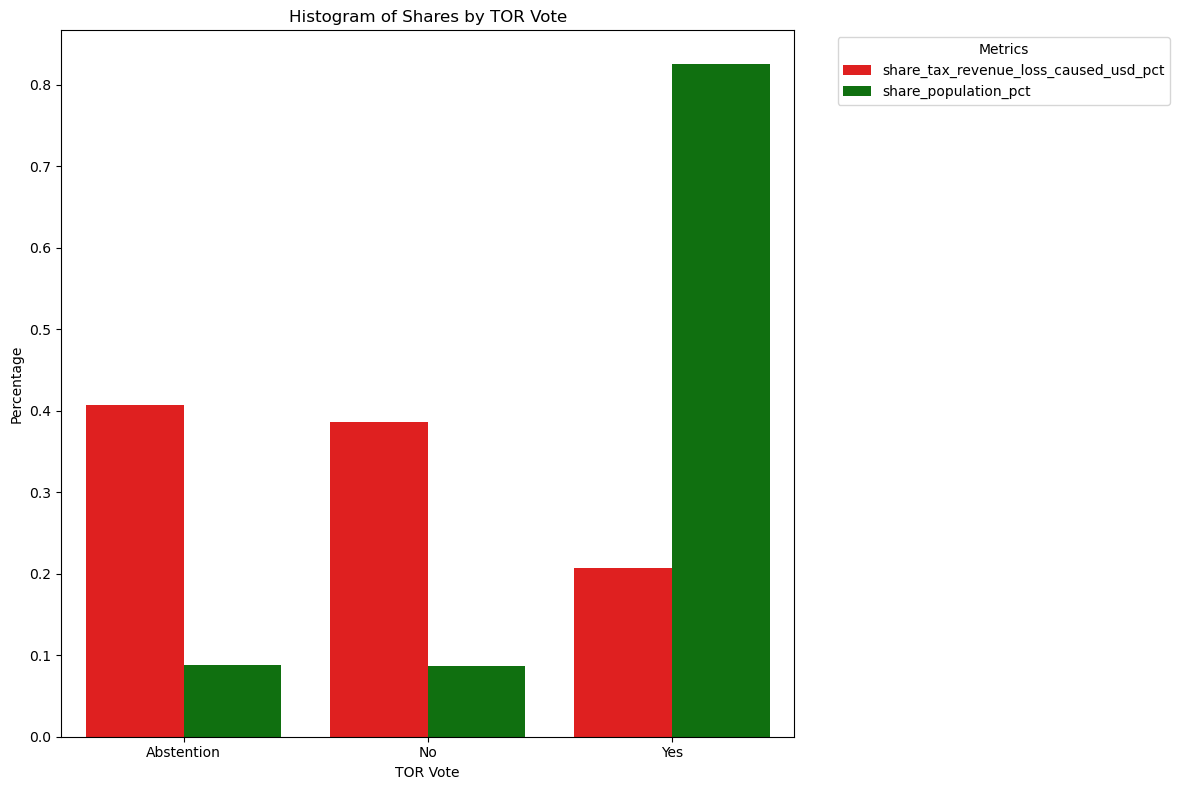

In [ ]:
# Melt the data to have 'Metric' and 'Value' columns
melted_data = pivot_data.melt(id_vars='TOR_vote', 
                              value_vars=['share_tax_revenue_loss_caused_usd_pct', 
                                          'share_population_pct'],
                              var_name='Metric', value_name='Value')

# Define custom color palette
custom_palette = {'share_tax_revenue_loss_caused_usd_pct': 'red', 
                  'share_population_pct': 'green'}

# Create the barplot with hue for each metric
plt.figure(figsize=(12, 8))
sns.barplot(
    data=melted_data,
    x='TOR_vote',
    y='Value',
    hue='Metric',
    palette=custom_palette
)

# Add legend, labels, and title
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('TOR Vote')
plt.ylabel('Percentage')
plt.title('Histogram of Shares by TOR Vote')

# Show the plot
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

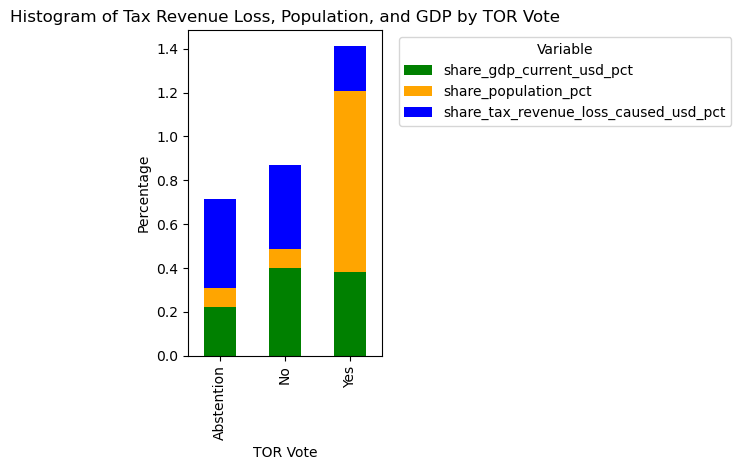

In [ ]:
filtered_data = grouped_data.dropna(subset=['TOR_vote', 'share_tax_revenue_loss_caused_usd_pct', 'share_population_pct', 'share_gdp_current_usd_pct'])

# Melt the DataFrame to long format
melted_data = filtered_data.melt(id_vars=['TOR_vote'], 
                                 value_vars=['share_tax_revenue_loss_caused_usd_pct', 'share_population_pct', 'share_gdp_current_usd_pct'],
                                 var_name='Variable', 
                                 value_name='Value')

# Pivot the DataFrame to wide format
pivoted_data = melted_data.pivot_table(index='TOR_vote', 
                                       columns='Variable', 
                                       values='Value').reset_index()

# Define a custom color palette
custom_palette = {'share_tax_revenue_loss_caused_usd_pct': 'blue', 
                  'share_population_pct': 'orange', 
                  'share_gdp_current_usd_pct': 'green'}

# Create the histogram
plt.figure(figsize=(12, 8))
pivoted_data.plot(kind='bar', x='TOR_vote', stacked=True, color=[custom_palette[col] for col in pivoted_data.columns if col != 'TOR_vote'])

# Add labels and title
plt.xlabel('TOR Vote')
plt.ylabel('Percentage')
plt.title('Histogram of Tax Revenue Loss, Population, and GDP by TOR Vote')
plt.legend(title='Variable', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

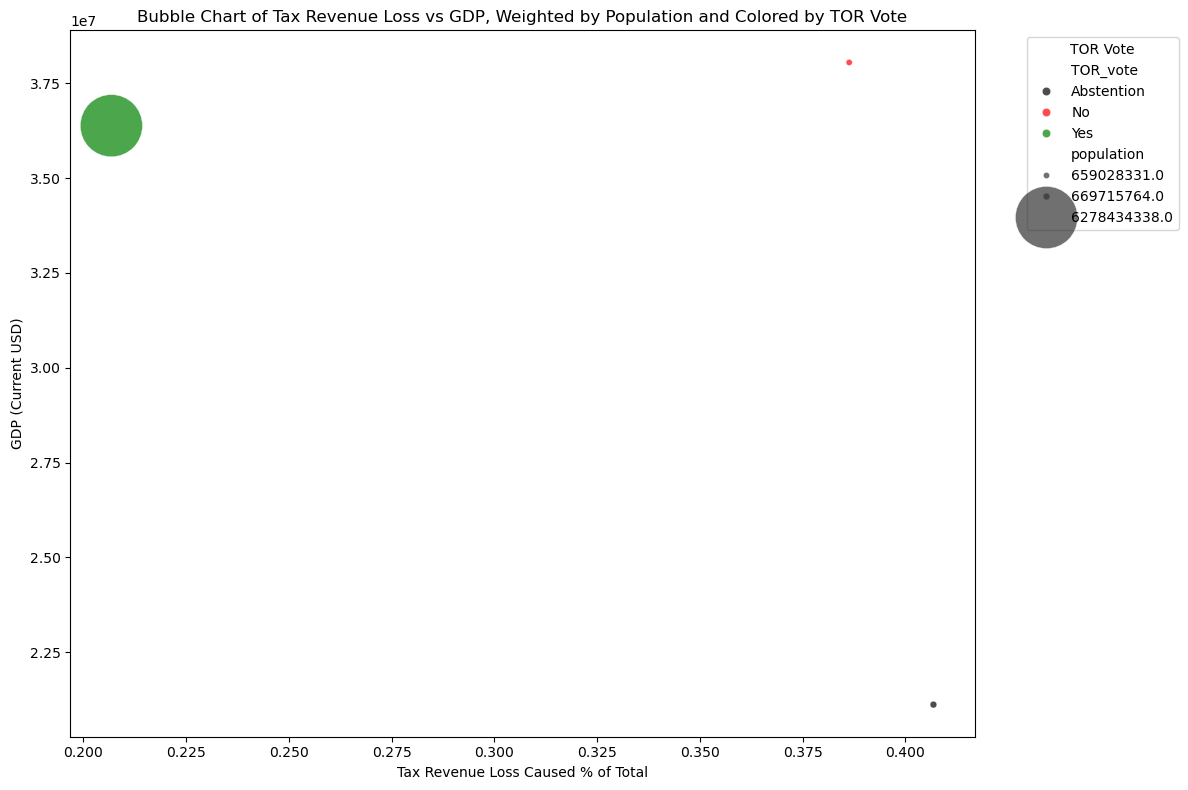

In [ ]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = grouped_data.dropna(subset=['tax_revenue_loss_caused_usd_pct', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'black', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='tax_revenue_loss_caused_usd_pct',
    y='gdp_current_usd',
    size='population',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette= custom_palette,  # You can choose a different color palette if you prefer
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Tax Revenue Loss Caused % of Total')
plt.ylabel('GDP (Current USD)')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

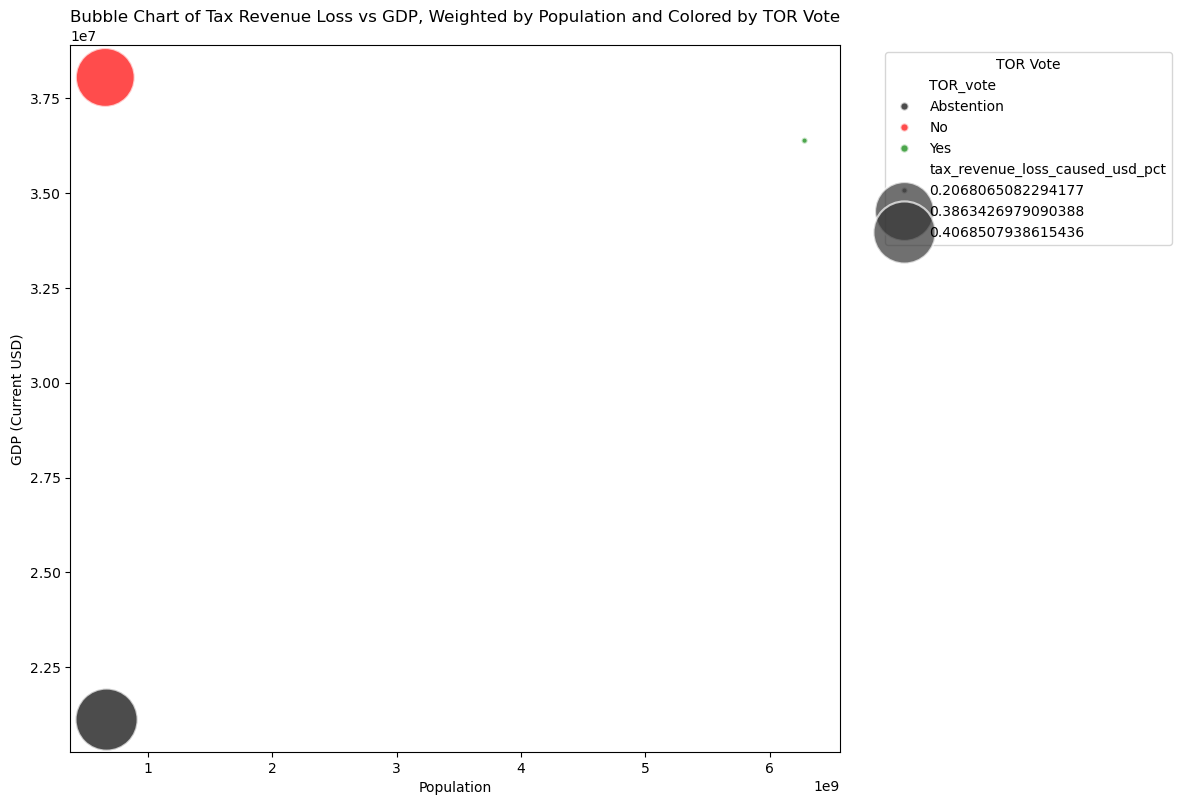

In [ ]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = grouped_data.dropna(subset=['tax_revenue_loss_caused_usd_pct', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'black', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='population',
    y='gdp_current_usd',
    size='tax_revenue_loss_caused_usd_pct',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette= custom_palette,  # You can choose a different color palette if you prefer
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Population')
plt.ylabel('GDP (Current USD)')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

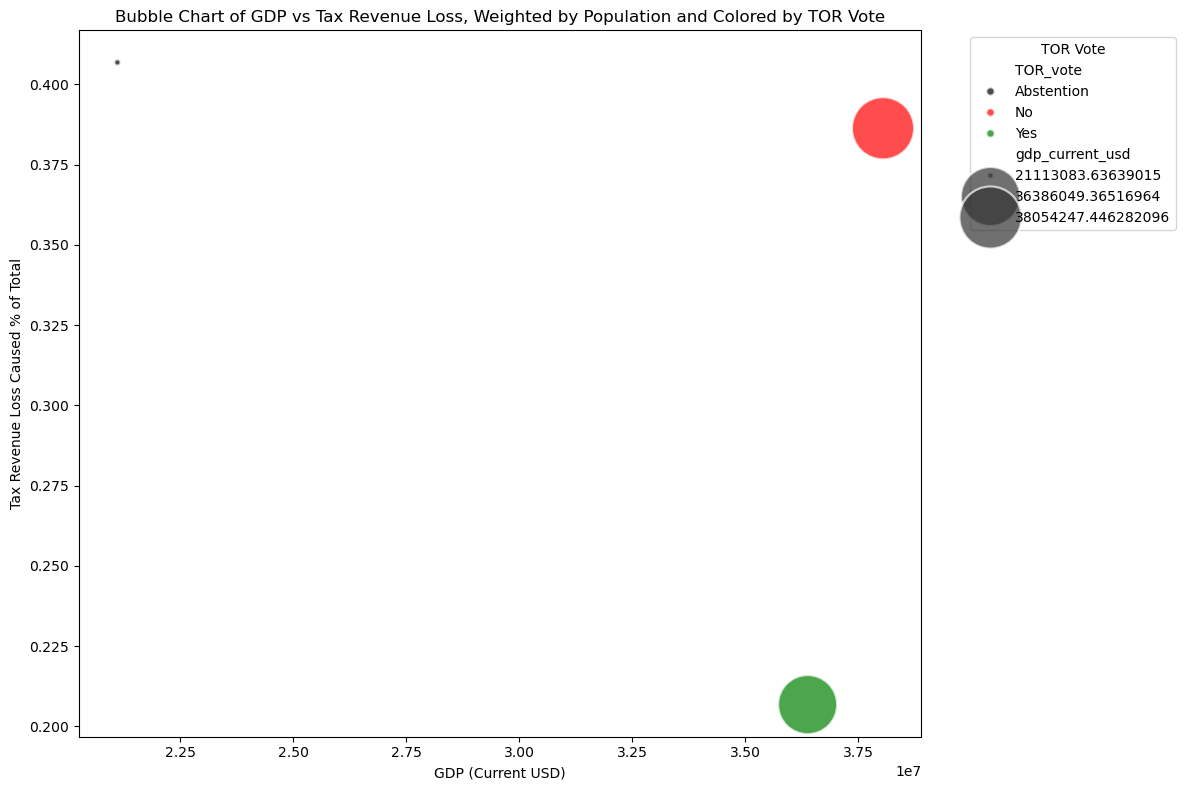

In [ ]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = grouped_data.dropna(subset=['tax_revenue_loss_caused_usd_pct', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'black', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='gdp_current_usd',
    y='tax_revenue_loss_caused_usd_pct',
    size='gdp_current_usd',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('GDP (Current USD)')
plt.ylabel('Tax Revenue Loss Caused % of Total')
plt.title('Bubble Chart of GDP vs Tax Revenue Loss, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = killer_graph_data.dropna(subset=['tax_revenue_loss_caused_usd_pct', 'gdp_current_usd', 'population', 'TOR_vote'])

# Create a new column for bubble size by combining population and GDP
filtered_data['bubble_size'] = filtered_data['population'] * filtered_data['gdp_current_usd']

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'black', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='tax_revenue_loss_caused_usd_pct',
    y='gdp_current_usd',
    size='bubble_size',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Tax Revenue Loss Caused % of Total')
plt.ylabel('GDP (Current USD)')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

KeyError: ['tax_revenue_loss_caused_usd_pct']

Figure 1. Scatterplot of countries showing 'Share of global tax losses responsible for, %' (tax_revenue_loss_caused_pct_of_total) and 'Tax losses suffered, as % of public health budget' (tax_revenue_loss_pct_of_gvt_health_expenditure) with colour of dots reflecting 'Vote on ToRs (Aug24)'

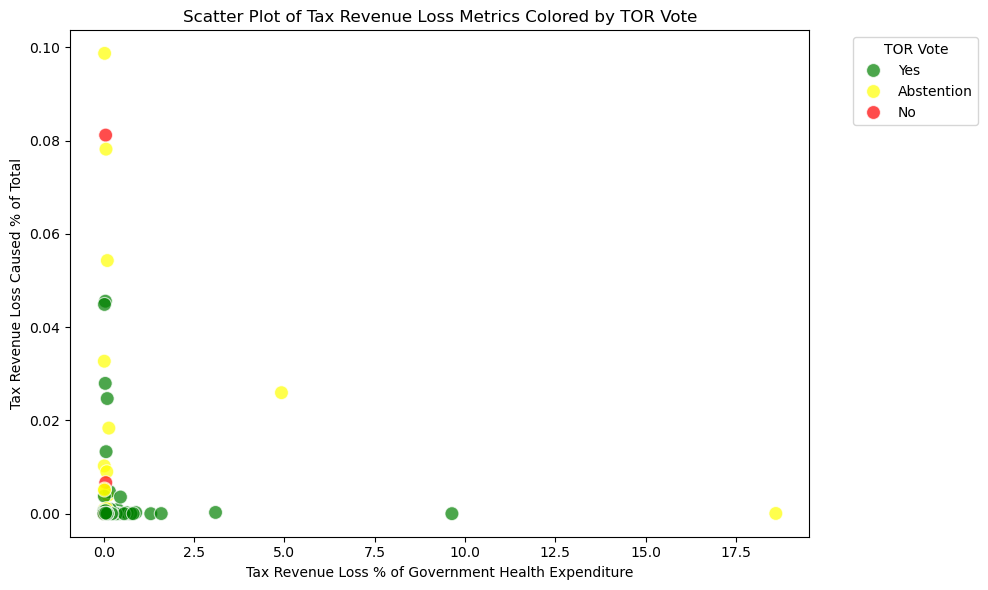

In [ ]:
# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'yellow', 'No': 'red'}

# Create the scatter plot with the custom color palette
plt.figure(figsize=(10, 6))
scatter_plot = sns.scatterplot(
    data=filtered_data,
    x='tax_revenue_loss_pct_of_gvt_health_expenditure',
    y='tax_revenue_loss_caused_pct_of_total',
    hue='TOR_vote',
    palette=custom_palette,
    s=100,  # Size of the points
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Tax Revenue Loss % of Government Health Expenditure')
plt.ylabel('Tax Revenue Loss Caused % of Total')
plt.title('Scatter Plot of Tax Revenue Loss Metrics Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


Figure 2. Bubblechart of countries showing 'Share of global tax losses responsible for, %' (y-axis) and 'Vote on ToRs (Aug24)' (x-axis), with dots scaled by population

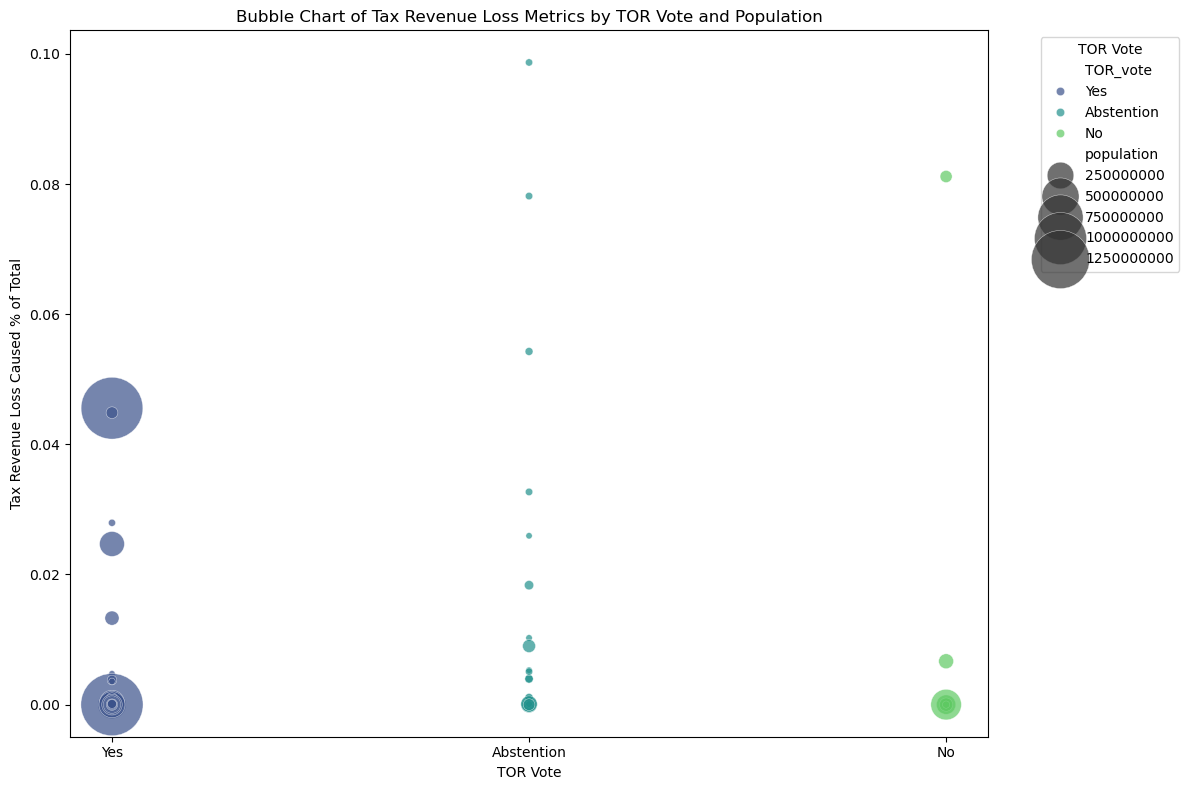

In [ ]:
# Filter out rows with NaN values in the relevant columns
filtered_data = sotj_tor_data_2021.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'TOR_vote', 'population'])

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='TOR_vote',
    y='tax_revenue_loss_caused_pct_of_total',
    size='population',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette='viridis',  # You can choose a different color palette if you prefer
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('TOR Vote')
plt.ylabel('Tax Revenue Loss Caused % of Total')
plt.title('Bubble Chart of Tax Revenue Loss Metrics by TOR Vote and Population')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()